In [10]:
import numpy as np
import setup as stp
import Maxwell2D as Max
import mesh_reader as msh
import matplotlib.pyplot as plt

N =  3

VX, VY, EToV, BCTags = msh.MeshReader2D('pi.msh')
#VX, VY, EToV, BCTags = msh.MeshReader2D_v4('pi4.msh')

malha = stp.StartUp2D(N,EToV,VX,VY)

area_total = np.sum(malha.J)/(2*malha.N)
print(f"Área total do domínio Numérico: {area_total:.10f}")
print((2*np.pi)**2)

Ez = np.zeros((malha.Np,malha.K),dtype=np.float64)
Ez = np.sin(malha.x)*np.sin(malha.y)
Hx = np.zeros((malha.Np,malha.K), dtype=np.float64)
Hy = np.zeros((malha.Np,malha.K),dtype= np.float64)

FinalTime = 10

Hx, Hy, Ez, pp, t, erro = Max.Maxwell2D(Hx,Hy,Ez,FinalTime,malha)

Malha carregada com sucesso!
Número de vértices: 441
Número de Elementos (K): 800
Área total do domínio Numérico: 32.8986813370
39.47841760435743
Tempo atual: 1.5985e-02 / 1.0000e+01
Tempo atual: 3.1969e-02 / 1.0000e+01
Tempo atual: 4.7954e-02 / 1.0000e+01
Tempo atual: 6.3939e-02 / 1.0000e+01
Tempo atual: 7.9924e-02 / 1.0000e+01
Tempo atual: 9.5908e-02 / 1.0000e+01
Tempo atual: 1.1189e-01 / 1.0000e+01
Tempo atual: 1.2788e-01 / 1.0000e+01
Tempo atual: 1.4386e-01 / 1.0000e+01
Tempo atual: 1.5985e-01 / 1.0000e+01
Tempo atual: 1.7583e-01 / 1.0000e+01
Tempo atual: 1.9182e-01 / 1.0000e+01
Tempo atual: 2.0780e-01 / 1.0000e+01
Tempo atual: 2.2379e-01 / 1.0000e+01
Tempo atual: 2.3977e-01 / 1.0000e+01
Tempo atual: 2.5576e-01 / 1.0000e+01
Tempo atual: 2.7174e-01 / 1.0000e+01
Tempo atual: 2.8772e-01 / 1.0000e+01
Tempo atual: 3.0371e-01 / 1.0000e+01
Tempo atual: 3.1969e-01 / 1.0000e+01
Tempo atual: 3.3568e-01 / 1.0000e+01
Tempo atual: 3.5166e-01 / 1.0000e+01
Tempo atual: 3.6765e-01 / 1.0000e+01
Tem

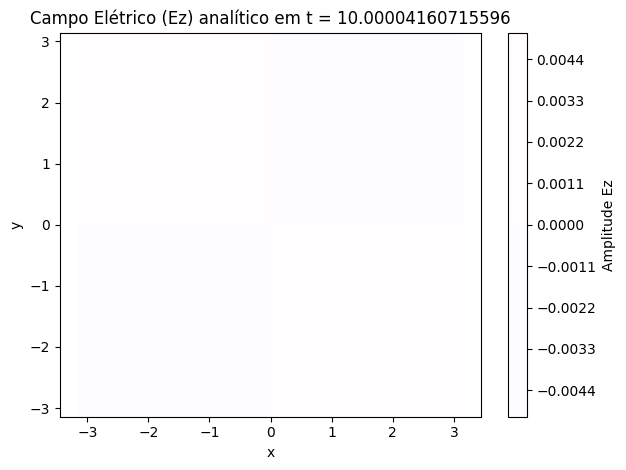

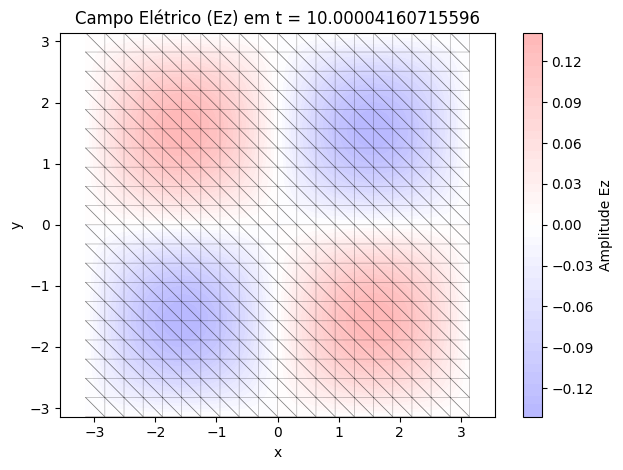

--- Análise de Erro (t = 10.0000) ---
Norma L-infinito (Máx): 1.3479e-01
Norma L2 Relativa:      2.6810e+01


Erro L2 Contínuo (Real): 2.6810e+01
Erro L2 Contínuo (Massa Exata): 2.6810e+01


In [11]:

x_plot = malha.x.flatten(order='F')
y_plot = malha.y.flatten(order='F')
Ez_plot = Ez.flatten(order='F')

######## Solução teórica

Ez_analitico = np.sin(malha.x)*np.sin(malha.y)*np.cos(np.sqrt(2)*t[-1])

x_plot2 = malha.x.flatten(order='F')
y_plot2 = malha.y.flatten(order='F')
Ez_plot2 = Ez_analitico.flatten(order='F')

plt.figure()
plt.title(f'Campo Elétrico (Ez) analítico em t = {t[-1]}')

grafico = plt.tricontourf(x_plot2, y_plot2, Ez_plot2, levels=100, cmap='seismic',vmin=-1,vmax=1)
plt.colorbar(grafico, label='Amplitude Ez')

plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()

plt.show()

vmin = np.min(Ez_plot2)
vmax = np.max(Ez_plot2)

plt.figure()
plt.title(f'Campo Elétrico (Ez) em t = {t[-1]}')

grafico = plt.tricontourf(x_plot, y_plot, Ez_plot, levels=100, cmap='seismic',vmin=-1,vmax=1)
plt.colorbar(grafico, label='Amplitude Ez')

plt.plot(VX[EToV].T, VY[EToV].T, color='k', linewidth=0.5, alpha=0.3)

plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()

plt.show()



# 2. Norma L-infinito (Erro Máximo Absoluto)
# Ótimo para ver se existe algum "pico" de erro escondido em algum triângulo
erro_Linf = np.max(np.abs(Ez - Ez_analitico))

# 3. Norma L2 Relativa (A mais usada em artigos científicos)
# Mostra o erro percentual global de energia na malha
erro_L2 = np.linalg.norm(Ez - Ez_analitico) / np.linalg.norm(Ez_analitico)

print(f"--- Análise de Erro (t = {t[-1]:.4f}) ---")
print(f"Norma L-infinito (Máx): {erro_Linf:.4e}")
print(f"Norma L2 Relativa:      {erro_L2:.4e}")

print('\n')

#Ez = pp[-2]

erro_quadrado = (Ez - Ez_analitico)**2
integral_erro = np.sum(malha.J * erro_quadrado) 
En = np.sqrt(integral_erro)

analitico_quadrado = Ez_analitico**2
integral_analitico = np.sum(malha.J * analitico_quadrado)
wt = np.sqrt(integral_analitico)

erro_L2_real = En / wt

print(f"Erro L2 Contínuo (Real): {erro_L2_real:.4e}")


# 1. Recuperamos a Matriz de Massa do triângulo de referência.
# Se o seu 'setup.py' não exporta a matriz M, nós calculamos ela aqui na hora
# usando a Matriz de Vandermonde (V): M = (V * V^T)^-1
M = np.linalg.inv(malha.V @ malha.V.T) 

# 2. O vetor de diferença nodal
erro_nodal = Ez - Ez_analitico

# 3. Integração Exata de Galerkin para o Numerador (Erro)
# (M @ erro_nodal) aplica os pesos da matriz de massa.
# erro_nodal * (...) faz o produto ponto a ponto (e^T * M * e).
# malha.J faz o escalonamento da área para o triângulo físico.
integral_erro_sq = np.sum(malha.J * (erro_nodal * (M @ erro_nodal)))
En = np.sqrt(integral_erro_sq)

# 4. Integração Exata para o Denominador (Analítico)
integral_analitico_sq = np.sum(malha.J * (Ez_analitico * (M @ Ez_analitico)))
wt = np.sqrt(integral_analitico_sq)

# 5. Erro Relativo Final
erro_L2_real = En / wt

print(f"Erro L2 Contínuo (Massa Exata): {erro_L2_real:.4e}")

Nó mais próximo encontrado em x = 1.57080, y = 1.57080


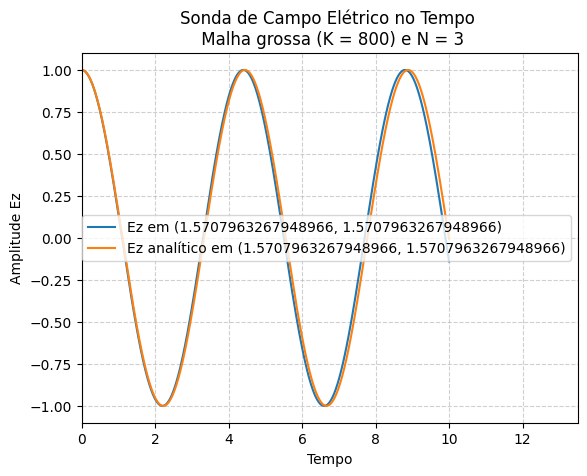

In [12]:
# 1. Defina o ponto onde você quer colocar a "sonda"
#x_alvo = 0.5
#y_alvo = 0.5

x_alvo = np.pi / 2.0
y_alvo = np.pi / 2.0

# 2. Calcula a distância geométrica de TODOS os nós para o alvo
distancias = np.sqrt((malha.x - x_alvo)**2 + (malha.y - y_alvo)**2)

indice_linear_mais_proximo = np.argmin(distancias)

# 4. Converte o índice linear de volta para as dimensões (Nó, Triângulo)
no_idx, tri_idx = np.unravel_index(indice_linear_mais_proximo, malha.x.shape)

print(f"Nó mais próximo encontrado em x = {malha.x[no_idx, tri_idx]:.5f}, y = {malha.y[no_idx, tri_idx]:.5f}")

# 5. Converte a sua lista do tempo para array do Numpy
pp_array = np.array(pp)
Ez_analiticot = np.zeros(len(t))
for n in range(len(t)):
    Ez_analiticot[n] = np.sin(malha.x[no_idx, tri_idx])*np.sin(malha.y[no_idx, tri_idx])*np.cos(np.sqrt(2)*t[n])
# 6. Extrai e plota a onda exatamente nesse nó ao longo de todo o tempo
plt.figure()
plt.plot(t, pp_array[:, no_idx, tri_idx], label=f'Ez em ({x_alvo}, {y_alvo})')
plt.plot(t,Ez_analiticot,label=f'Ez analítico em ({x_alvo}, {y_alvo})')

plt.title(f'Sonda de Campo Elétrico no Tempo \n Malha grossa (K = {malha.K}) e N = {N}')
plt.xlabel('Tempo')
plt.ylabel('Amplitude Ez')
plt.xlim(0,13.5)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

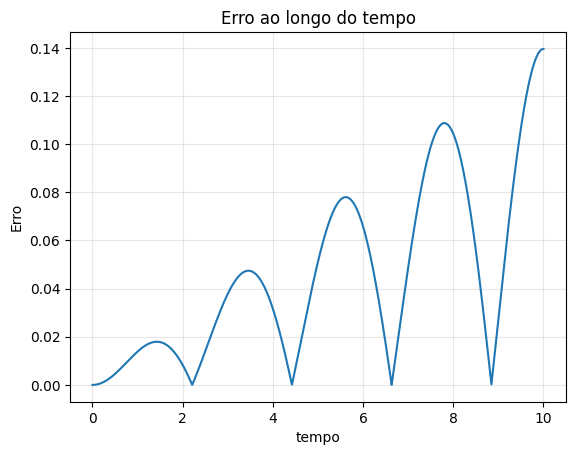

In [13]:
plt.figure()
plt.grid(alpha=0.3)
plt.title('Erro ao longo do tempo')
plt.plot(t,erro)
#plt.ylim(0,0.5)
plt.xlabel('tempo')
plt.ylabel('Erro')
plt.show()